In [1]:
"""
SPRINT 2 - Análise Exploratória de Dados (EDA)
Desafio InsightFlow
"""

# Importações básicas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import warnings
from datetime import datetime, timedelta
import os

# Ignorar warnings
warnings.filterwarnings('ignore')

# Configurações de visualização
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.2f' % x)
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("viridis")
plt.rcParams['figure.figsize'] = (12, 6)

print("✅ Bibliotecas importadas com sucesso!")
print(f"📊 Versão do Pandas: {pd.__version__}")
print(f"📈 Versão do Seaborn: {sns.__version__}")

✅ Bibliotecas importadas com sucesso!
📊 Versão do Pandas: 2.3.3
📈 Versão do Seaborn: 0.13.2


In [2]:
# Caminho para o banco de dados (ajuste se necessário)
caminho_db = os.path.join('..', 'database', 'ecom.db')
# Alternativa para Windows:
# caminho_db = r'..\database\ecom.db'

# Conectar ao SQLite
conn = sqlite3.connect(caminho_db)

# Carregar dados
query = "SELECT * FROM vendas;"
df = pd.read_sql_query(query, conn)

print(f"✅ Dados carregados com sucesso!")
print(f"📊 Shape: {df.shape[0]} linhas x {df.shape[1]} colunas")
print(f"\n📋 Primeiras 5 linhas:")
df.head()

✅ Dados carregados com sucesso!
📊 Shape: 5390 linhas x 7 colunas

📋 Primeiras 5 linhas:


,ID_Transacao,Data_Venda,ID_Cliente,Nome_Produto,Categoria_Produto,Valor_Unitario,Quantidade
0,TXN000001,2023-05-18 00:00:00,9005,Fone De Ouvido,Eletrônicos,780.35,2
1,TXN000002,2023-10-06 00:00:00,2403,Halter,Esportes,571.66,2
2,TXN000003,2024-12-04 00:00:00,9005,Tênis De Corrida,Esportes,445.90,1
3,TXN000004,2023-04-05 00:00:00,8260,Ficção Científica,Livros,95.82,1
4,TXN000005,2023-05-14 00:00:00,6310,Casaco,Roupas,94.89,4


In [3]:
# Informações dos tipos de dados
print("📋 Informações do Dataset:")
print("-" * 50)
df.info()

print("\n📊 Estatísticas Descritivas - Colunas Numéricas:")
print("-" * 50)
df[['Valor_Unitario', 'Quantidade']].describe()

📋 Informações do Dataset:
--------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5390 entries, 0 to 5389
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   ID_Transacao       5390 non-null   object 
 1   Data_Venda         5390 non-null   object 
 2   ID_Cliente         5390 non-null   object 
 3   Nome_Produto       5390 non-null   object 
 4   Categoria_Produto  5390 non-null   object 
 5   Valor_Unitario     5390 non-null   float64
 6   Quantidade         5390 non-null   int64  
dtypes: float64(1), int64(1), object(5)
memory usage: 294.9+ KB

📊 Estatísticas Descritivas - Colunas Numéricas:
--------------------------------------------------


,Valor_Unitario,Quantidade
count,5390.00,5390.00
mean,417.07,2.97
std,429.66,1.42
min,10.02,1.00
25%,114.72,2.00
50%,294.53,3.00
75%,523.00,4.00
max,1998.86,5.00


In [4]:
# Converter Data_Venda para datetime (garantindo)
df['Data_Venda'] = pd.to_datetime(df['Data_Venda'])

# Criar colunas úteis para análise
df['Ano'] = df['Data_Venda'].dt.year
df['Mes'] = df['Data_Venda'].dt.month
df['Dia'] = df['Data_Venda'].dt.day
df['Dia_da_Semana'] = df['Data_Venda'].dt.day_name()
df['Trimestre'] = df['Data_Venda'].dt.quarter
df['Ano_Mes'] = df['Data_Venda'].dt.to_period('M').astype(str)

# Valor total da venda
df['Valor_Total'] = df['Valor_Unitario'] * df['Quantidade']

print("✅ Colunas derivadas criadas!")
print(f"Nova coluna 'Valor_Total' - Média: R$ {df['Valor_Total'].mean():.2f}")
print(f"Nova coluna 'Valor_Total' - Total: R$ {df['Valor_Total'].sum():.2f}")

✅ Colunas derivadas criadas!
Nova coluna 'Valor_Total' - Média: R$ 1239.67
Nova coluna 'Valor_Total' - Total: R$ 6681842.72


In [5]:
# Estatísticas completas incluindo Valor_Total
print("📊 ESTATÍSTICAS DESCRITIVAS COMPLETAS")
print("=" * 60)
desc_stats = df[['Valor_Unitario', 'Quantidade', 'Valor_Total']].describe()
display(desc_stats)

# Medidas adicionais
print("\n📈 MEDIDAS ADICIONAIS:")
print("-" * 60)
for col in ['Valor_Unitario', 'Quantidade', 'Valor_Total']:
    print(f"\n{col}:")
    print(f"  - Variância: {df[col].var():.2f}")
    print(f"  - Desvio Padrão: {df[col].std():.2f}")
    print(f"  - Coef. de Variação: {(df[col].std() / df[col].mean() * 100):.2f}%")

📊 ESTATÍSTICAS DESCRITIVAS COMPLETAS


,Valor_Unitario,Quantidade,Valor_Total
count,5390.00,5390.00,5390.00
mean,417.07,2.97,1239.67
std,429.66,1.42,1528.66
min,10.02,1.00,10.02
25%,114.72,2.00,280.01
50%,294.53,3.00,679.41
75%,523.00,4.00,1592.94
max,1998.86,5.00,9929.95



📈 MEDIDAS ADICIONAIS:
------------------------------------------------------------

Valor_Unitario:
  - Variância: 184608.55
  - Desvio Padrão: 429.66
  - Coef. de Variação: 103.02%

Quantidade:
  - Variância: 2.01
  - Desvio Padrão: 1.42
  - Coef. de Variação: 47.66%

Valor_Total:
  - Variância: 2336809.62
  - Desvio Padrão: 1528.66
  - Coef. de Variação: 123.31%


In [6]:
# Verificar valores nulos
print("🔍 VALORES NULOS:")
print("-" * 60)
nulos = df.isnull().sum()
nulos_percent = (df.isnull().sum() / len(df)) * 100
nulos_df = pd.DataFrame({
    'Valores Nulos': nulos,
    'Percentual (%)': nulos_percent
})
display(nulos_df[nulos_df['Valores Nulos'] > 0])

# Verificar duplicatas
print(f"\n📑 DUPLICATAS:")
print("-" * 60)
print(f"Linhas duplicadas: {df.duplicated().sum()}")
print(f"Percentual duplicado: {(df.duplicated().sum() / len(df) * 100):.2f}%")

🔍 VALORES NULOS:
------------------------------------------------------------


,Valores Nulos,Percentual (%)



📑 DUPLICATAS:
------------------------------------------------------------
Linhas duplicadas: 0
Percentual duplicado: 0.00%


In [7]:
# Análise por categoria
print("📊 ANÁLISE POR CATEGORIA")
print("=" * 60)

categoria_analise = df.groupby('Categoria_Produto').agg({
    'ID_Transacao': 'count',
    'ID_Cliente': 'nunique',
    'Quantidade': 'sum',
    'Valor_Total': ['sum', 'mean', 'std']
}).round(2)

# Renomear colunas
categoria_analise.columns = ['Total_Vendas', 'Clientes_Unicos', 'Unidades_Vendidas', 
                             'Receita_Total', 'Ticket_Medio', 'Std_Receita']
categoria_analise = categoria_analise.reset_index()

# Adicionar percentual
categoria_analise['%_Receita'] = (categoria_analise['Receita_Total'] / 
                                  categoria_analise['Receita_Total'].sum() * 100).round(2)

# Ordenar por receita
categoria_analise = categoria_analise.sort_values('Receita_Total', ascending=False)

display(categoria_analise)

# Salvar para dashboard
categoria_analise.to_csv(os.path.join('..', 'data', 'analise_categorias.csv'), index=False)
print("\n✅ Arquivo 'analise_categorias.csv' salvo para o dashboard!")

📊 ANÁLISE POR CATEGORIA


,Categoria_Produto,Total_Vendas,Clientes_Unicos,Unidades_Vendidas,Receita_Total,Ticket_Medio,Std_Receita,%_Receita
1,Eletrônicos,1101,295,3329,3302278.00,2999.34,2315.15,49.42
0,Casa e Cozinha,1138,292,3413,1374832.37,1208.11,935.44,20.58
2,Esportes,1029,293,3033,927707.38,901.56,679.69,13.88
4,Roupas,1052,288,3109,822199.03,781.56,596.69,12.30
3,Livros,1070,293,3149,254825.94,238.16,170.69,3.81



✅ Arquivo 'analise_categorias.csv' salvo para o dashboard!


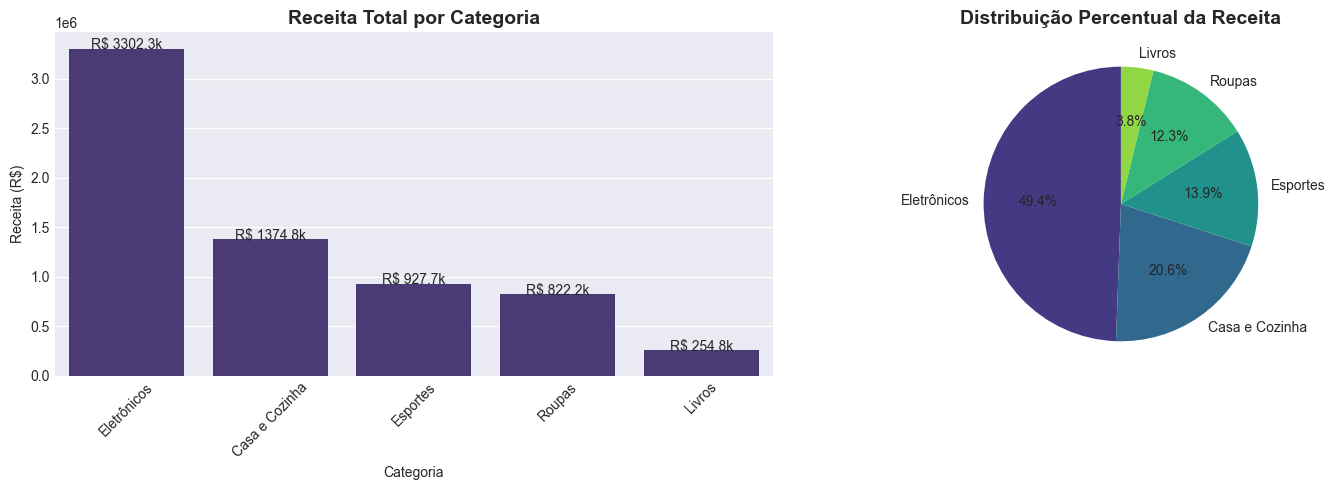

In [8]:
# Gráfico de barras - Receita por Categoria
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Gráfico 1: Receita Total
sns.barplot(data=categoria_analise, x='Categoria_Produto', y='Receita_Total', ax=axes[0])
axes[0].set_title('Receita Total por Categoria', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Categoria')
axes[0].set_ylabel('Receita (R$)')
axes[0].tick_params(axis='x', rotation=45)

# Adicionar valores nas barras
for i, v in enumerate(categoria_analise['Receita_Total']):
    axes[0].text(i, v + 500, f'R$ {v/1000:.1f}k', ha='center', fontsize=10)

# Gráfico 2: Percentual de Receita
cores = sns.color_palette('viridis', len(categoria_analise))
axes[1].pie(categoria_analise['%_Receita'], labels=categoria_analise['Categoria_Produto'], 
            autopct='%1.1f%%', colors=cores, startangle=90)
axes[1].set_title('Distribuição Percentual da Receita', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

In [9]:
# Análise mensal
print("📅 ANÁLISE TEMPORAL - MENSAL")
print("=" * 60)

# Agrupar por mês
vendas_mensais = df.groupby('Ano_Mes').agg({
    'ID_Transacao': 'count',
    'ID_Cliente': 'nunique',
    'Valor_Total': ['sum', 'mean', 'std']
}).round(2)

vendas_mensais.columns = ['Qtd_Vendas', 'Clientes_Ativos', 'Receita_Total', 
                          'Ticket_Medio', 'Std_Receita']
vendas_mensais = vendas_mensais.reset_index()
vendas_mensais['Data'] = pd.to_datetime(vendas_mensais['Ano_Mes'] + '-01')
vendas_mensais = vendas_mensais.sort_values('Data')

# Adicionar colunas de crescimento
vendas_mensais['Crescimento_Receita'] = vendas_mensais['Receita_Total'].pct_change() * 100
vendas_mensais['Crescimento_Receita'] = vendas_mensais['Crescimento_Receita'].round(2)

print("Primeiros 6 meses:")
display(vendas_mensais.head(6))

# Salvar para dashboard
vendas_mensais.to_csv(os.path.join('..', 'data', 'vendas_mensais.csv'), index=False)
print("\n✅ Arquivo 'vendas_mensais.csv' salvo para o dashboard!")

📅 ANÁLISE TEMPORAL - MENSAL
Primeiros 6 meses:


,Ano_Mes,Qtd_Vendas,Clientes_Ativos,Receita_Total,Ticket_Medio,Std_Receita,Data,Crescimento_Receita
0,2023-01,217,155,245891.95,1133.14,1560.74,2023-01-01,NaN
1,2023-02,226,167,279206.47,1235.43,1466.96,2023-02-01,13.55
2,2023-03,234,165,303724.61,1297.97,1566.16,2023-03-01,8.78
3,2023-04,248,174,338174.58,1363.61,1623.09,2023-04-01,11.34
4,2023-05,220,151,296276.78,1346.71,1639.85,2023-05-01,-12.39
5,2023-06,208,161,249920.45,1201.54,1432.01,2023-06-01,-15.65



✅ Arquivo 'vendas_mensais.csv' salvo para o dashboard!


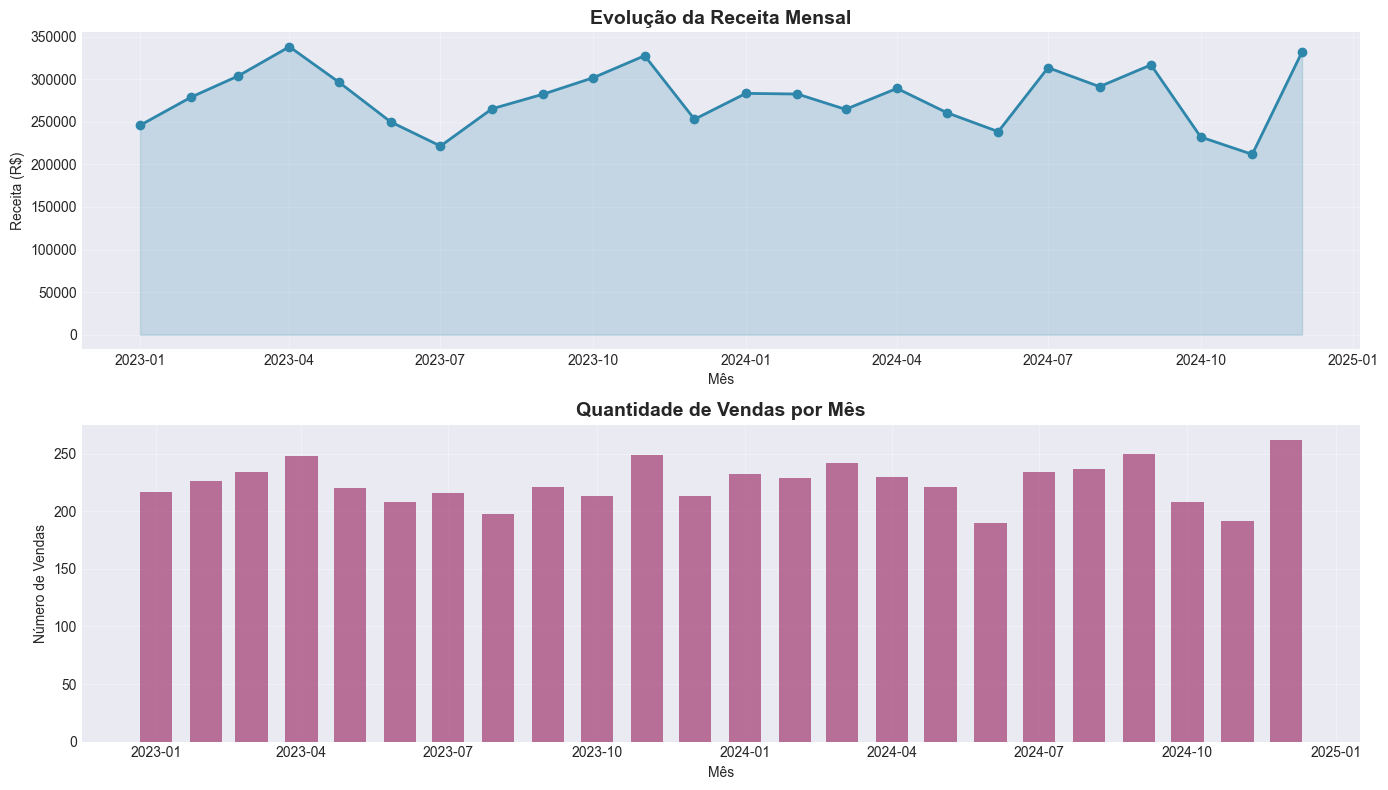

In [10]:
# Gráfico de série temporal
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Gráfico 1: Receita Mensal
axes[0].plot(vendas_mensais['Data'], vendas_mensais['Receita_Total'], 
             marker='o', linewidth=2, markersize=6, color='#2E86AB')
axes[0].fill_between(vendas_mensais['Data'], vendas_mensais['Receita_Total'], alpha=0.2, color='#2E86AB')
axes[0].set_title('Evolução da Receita Mensal', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Mês')
axes[0].set_ylabel('Receita (R$)')
axes[0].grid(True, alpha=0.3)

# Gráfico 2: Quantidade de Vendas Mensais
axes[1].bar(vendas_mensais['Data'], vendas_mensais['Qtd_Vendas'], 
            width=20, color='#A23B72', alpha=0.7)
axes[1].set_title('Quantidade de Vendas por Mês', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Mês')
axes[1].set_ylabel('Número de Vendas')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

📊 ANÁLISE DE SAZONALIDADE


,Dia_PT,Qtd_Vendas,Receita_Total,Ticket_Medio
1,Segunda,793,989745.02,1248.10
5,Terça,748,904726.44,1209.53
6,Quarta,776,948485.81,1222.28
4,Quinta,796,979189.99,1230.14
0,Sexta,781,1029301.53,1317.93
2,Sábado,736,946497.64,1286.00
3,Domingo,760,883896.29,1163.02


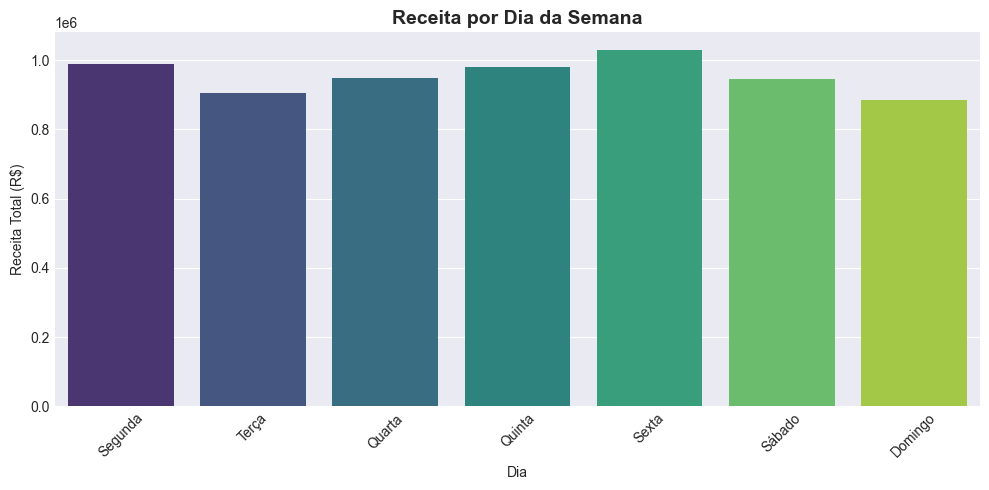

In [11]:
# Análise por dia da semana
print("📊 ANÁLISE DE SAZONALIDADE")
print("=" * 60)

# Ordem dos dias
ordem_dias = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dias_pt = ['Segunda', 'Terça', 'Quarta', 'Quinta', 'Sexta', 'Sábado', 'Domingo']

# Agrupar por dia da semana
vendas_dia = df.groupby('Dia_da_Semana').agg({
    'ID_Transacao': 'count',
    'Valor_Total': ['sum', 'mean']
}).round(2)

vendas_dia.columns = ['Qtd_Vendas', 'Receita_Total', 'Ticket_Medio']
vendas_dia = vendas_dia.reset_index()
vendas_dia['Dia_Ordem'] = vendas_dia['Dia_da_Semana'].map(dict(zip(ordem_dias, range(7))))
vendas_dia = vendas_dia.sort_values('Dia_Ordem')
vendas_dia['Dia_PT'] = dias_pt

display(vendas_dia[['Dia_PT', 'Qtd_Vendas', 'Receita_Total', 'Ticket_Medio']])

# Gráfico
plt.figure(figsize=(10, 5))
sns.barplot(data=vendas_dia, x='Dia_PT', y='Receita_Total', palette='viridis')
plt.title('Receita por Dia da Semana', fontsize=14, fontweight='bold')
plt.xlabel('Dia')
plt.ylabel('Receita Total (R$)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

🔍 IDENTIFICAÇÃO DE OUTLIERS

📊 Análise para 'Valor_Total':
  - Limite Inferior: R$ -1689.38
  - Limite Superior: R$ 3562.33
  - Total de outliers: 403 (7.48%)
  - Valor mínimo outlier: R$ 3564.78
  - Valor máximo outlier: R$ 9929.95


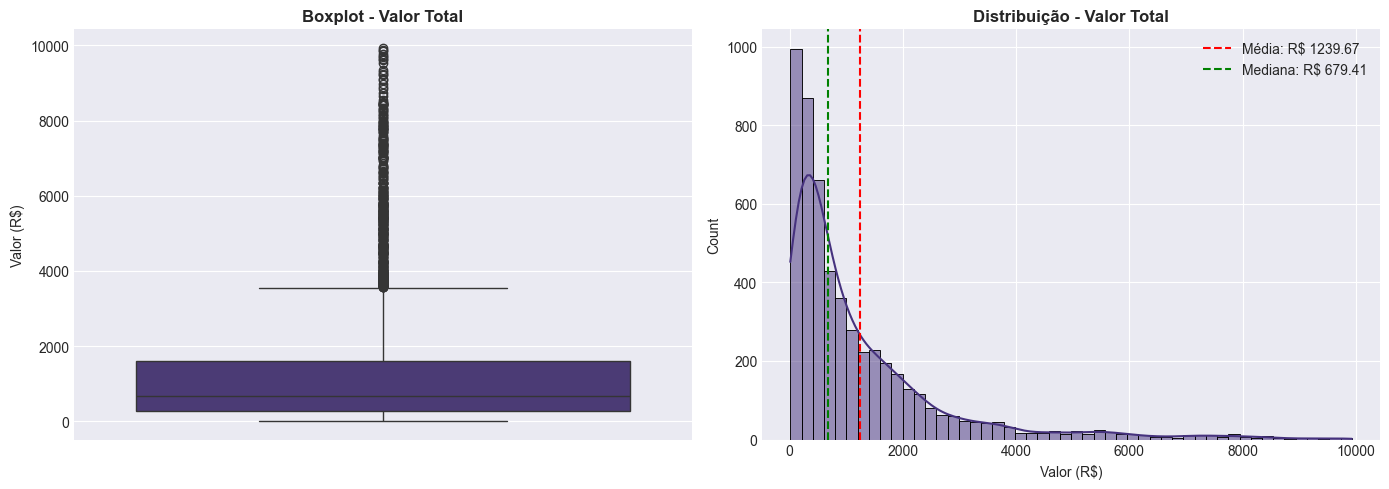

In [12]:
print("🔍 IDENTIFICAÇÃO DE OUTLIERS")
print("=" * 60)

def detectar_outliers_iqr(df, coluna):
    """
    Detecta outliers usando o método IQR
    """
    Q1 = df[coluna].quantile(0.25)
    Q3 = df[coluna].quantile(0.75)
    IQR = Q3 - Q1
    
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    
    outliers = df[(df[coluna] < limite_inferior) | (df[coluna] > limite_superior)]
    
    return outliers, limite_inferior, limite_superior

# Analisar outliers para Valor_Total
outliers_valor, lim_inf, lim_sup = detectar_outliers_iqr(df, 'Valor_Total')

print(f"\n📊 Análise para 'Valor_Total':")
print(f"  - Limite Inferior: R$ {lim_inf:.2f}")
print(f"  - Limite Superior: R$ {lim_sup:.2f}")
print(f"  - Total de outliers: {len(outliers_valor)} ({len(outliers_valor)/len(df)*100:.2f}%)")
print(f"  - Valor mínimo outlier: R$ {outliers_valor['Valor_Total'].min():.2f}")
print(f"  - Valor máximo outlier: R$ {outliers_valor['Valor_Total'].max():.2f}")

# Visualização
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot
sns.boxplot(y=df['Valor_Total'], ax=axes[0])
axes[0].set_title('Boxplot - Valor Total', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Valor (R$)')

# Histograma
sns.histplot(df['Valor_Total'], bins=50, kde=True, ax=axes[1])
axes[1].set_title('Distribuição - Valor Total', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Valor (R$)')
axes[1].axvline(df['Valor_Total'].mean(), color='red', linestyle='--', 
                label=f'Média: R$ {df["Valor_Total"].mean():.2f}')
axes[1].axvline(df['Valor_Total'].median(), color='green', linestyle='--', 
                label=f'Mediana: R$ {df["Valor_Total"].median():.2f}')
axes[1].legend()

plt.tight_layout()
plt.show()

📈 ANÁLISE DE CORRELAÇÃO
Matriz de Correlação:


,Valor_Unitario,Quantidade,Valor_Total,Ano,Mes
Valor_Unitario,1.00,-0.00,0.84,0.00,-0.00
Quantidade,-0.00,1.00,0.38,-0.03,0.01
Valor_Total,0.84,0.38,1.00,-0.02,0.01
Ano,0.00,-0.03,-0.02,1.00,0.00
Mes,-0.00,0.01,0.01,0.00,1.00


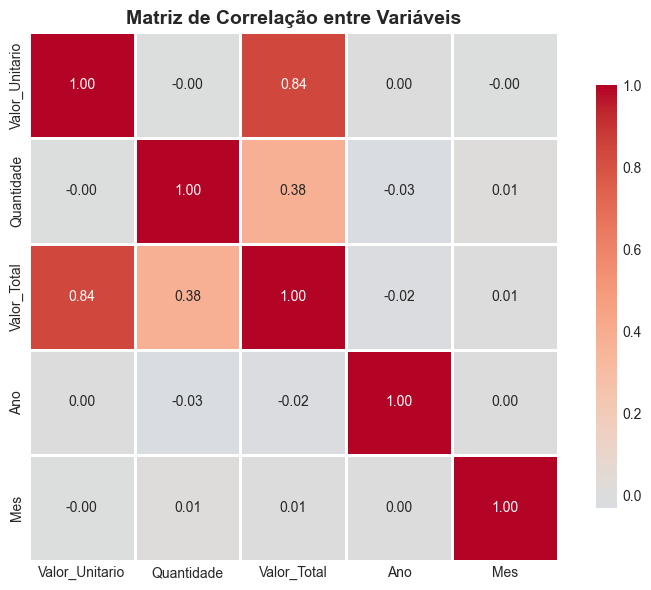


🔍 PRINCIPAIS CORRELAÇÕES:
  - Valor_Unitario x Valor_Total: 0.836
  - Quantidade x Valor_Total: 0.384


In [13]:
print("📈 ANÁLISE DE CORRELAÇÃO")
print("=" * 60)

# Selecionar colunas numéricas
colunas_numericas = ['Valor_Unitario', 'Quantidade', 'Valor_Total']
df_corr = df[colunas_numericas].copy()

# Adicionar variáveis temporais numéricas
df_corr['Ano'] = df['Ano']
df_corr['Mes'] = df['Mes']

# Calcular correlação
correlacao = df_corr.corr()

print("Matriz de Correlação:")
display(correlacao)

# Visualização
plt.figure(figsize=(8, 6))
sns.heatmap(correlacao, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8},
            fmt='.2f', annot_kws={'size': 10})
plt.title('Matriz de Correlação entre Variáveis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Insights de correlação
print("\n🔍 PRINCIPAIS CORRELAÇÕES:")
for i in range(len(correlacao.columns)):
    for j in range(i+1, len(correlacao.columns)):
        if abs(correlacao.iloc[i, j]) > 0.3:
            print(f"  - {correlacao.index[i]} x {correlacao.columns[j]}: {correlacao.iloc[i, j]:.3f}")

In [14]:
"""
🎯 SEGMENTAÇÃO RFM (Recency, Frequency, Monetary)
"""

print("🎯 ANÁLISE RFM - Segmentação de Clientes")
print("=" * 60)

# Data de referência (última data + 1 dia)
data_ref = df['Data_Venda'].max() + pd.Timedelta(days=1)
print(f"Data de referência: {data_ref.strftime('%Y-%m-%d')}")

# Calcular RFM
rfm = df.groupby('ID_Cliente').agg({
    'Data_Venda': lambda x: (data_ref - x.max()).days,  # Recência
    'ID_Transacao': 'count',                             # Frequência
    'Valor_Total': 'sum'                                  # Monetário
}).reset_index()

# Renomear colunas
rfm.columns = ['ID_Cliente', 'Recencia', 'Frequencia', 'Monetario']

print(f"\n📊 RFM calculado para {len(rfm)} clientes")
print("\nPrimeiros 5 clientes:")
display(rfm.head())

🎯 ANÁLISE RFM - Segmentação de Clientes
Data de referência: 2025-01-01

📊 RFM calculado para 300 clientes

Primeiros 5 clientes:


,ID_Cliente,Recencia,Frequencia,Monetario
0,1009,34,16,21085.27
1,1035,6,25,41571.49
2,1053,24,17,25381.66
3,1106,5,18,33339.32
4,1117,54,20,18117.19


In [15]:
# Criar scores de 1 a 5 para cada métrica
# Recência: quanto menor, melhor (mais recente)
rfm['R_Score'] = pd.qcut(rfm['Recencia'], 5, labels=[5, 4, 3, 2, 1])

# Frequência: quanto maior, melhor
rfm['F_Score'] = pd.qcut(rfm['Frequencia'].rank(method='first'), 5, labels=[1, 2, 3, 4, 5])

# Monetário: quanto maior, melhor
rfm['M_Score'] = pd.qcut(rfm['Monetario'], 5, labels=[1, 2, 3, 4, 5])

# Converter para inteiro
rfm['R_Score'] = rfm['R_Score'].astype(int)
rfm['F_Score'] = rfm['F_Score'].astype(int)
rfm['M_Score'] = rfm['M_Score'].astype(int)

# Score RFM combinado (soma)
rfm['RFM_Score'] = rfm['R_Score'] + rfm['F_Score'] + rfm['M_Score']

print("📊 Distribuição dos Scores RFM:")
print(f"R_Score (Recência):")
print(rfm['R_Score'].value_counts().sort_index())
print(f"\nF_Score (Frequência):")
print(rfm['F_Score'].value_counts().sort_index())
print(f"\nM_Score (Monetário):")
print(rfm['M_Score'].value_counts().sort_index())

📊 Distribuição dos Scores RFM:
R_Score (Recência):
R_Score
1    59
2    60
3    61
4    58
5    62
Name: count, dtype: int64

F_Score (Frequência):
F_Score
1    60
2    60
3    60
4    60
5    60
Name: count, dtype: int64

M_Score (Monetário):
M_Score
1    60
2    60
3    60
4    60
5    60
Name: count, dtype: int64


In [16]:
# Função para segmentar clientes baseado no RFM Score
def segmentar_cliente(score):
    if score >= 13:
        return 'Campeões'  # Clientes mais valiosos
    elif score >= 10:
        return 'Leais'      # Clientes fiéis
    elif score >= 7:
        return 'Promissores'# Clientes com potencial
    elif score >= 5:
        return 'Novatos'    # Clientes recentes
    else:
        return 'Em Risco'   # Clientes inativos

# Aplicar segmentação
rfm['Segmento'] = rfm['RFM_Score'].apply(segmentar_cliente)

# Análise dos segmentos
print("📊 DISTRIBUIÇÃO DOS SEGMENTOS")
print("=" * 60)

segmentos = rfm['Segmento'].value_counts().reset_index()
segmentos.columns = ['Segmento', 'Quantidade']
segmentos['Percentual'] = (segmentos['Quantidade'] / len(rfm) * 100).round(2)

display(segmentos)

# Estatísticas por segmento
print("\n📈 ESTATÍSTICAS POR SEGMENTO:")
segmento_stats = rfm.groupby('Segmento').agg({
    'Recencia': 'mean',
    'Frequencia': 'mean',
    'Monetario': ['mean', 'sum']
}).round(2)

segmento_stats.columns = ['Recencia_Media', 'Frequencia_Media', 'Ticket_Medio', 'Receita_Total']
segmento_stats = segmento_stats.reset_index()
display(segmento_stats)

# Salvar para dashboard
rfm.to_csv(os.path.join('..', 'data', 'rfm_segmentacao.csv'), index=False)
print("\n✅ Arquivo 'rfm_segmentacao.csv' salvo para o dashboard!")

📊 DISTRIBUIÇÃO DOS SEGMENTOS


,Segmento,Quantidade,Percentual
0,Promissores,99,33.00
1,Leais,89,29.67
2,Novatos,45,15.00
3,Campeões,42,14.00
4,Em Risco,25,8.33



📈 ESTATÍSTICAS POR SEGMENTO:


,Segmento,Recencia_Media,Frequencia_Media,Ticket_Medio,Receita_Total
0,Campeões,7.86,23.26,32274.04,1355509.58
1,Em Risco,96.44,12.64,12524.86,313121.46
2,Leais,29.38,19.82,26356.66,2345742.33
3,Novatos,66.42,14.42,16149.71,726737.02
4,Promissores,35.99,17.01,19603.36,1940732.33



✅ Arquivo 'rfm_segmentacao.csv' salvo para o dashboard!


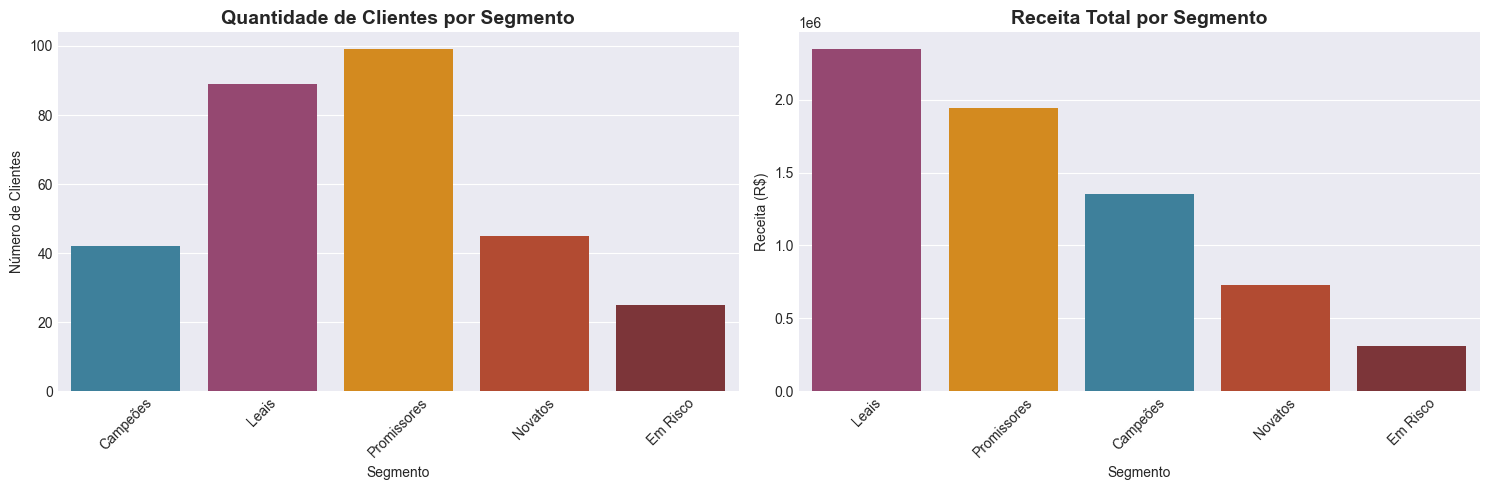

In [17]:
# Visualização dos segmentos
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Gráfico 1: Quantidade por Segmento
cores = {'Campeões': '#2E86AB', 'Leais': '#A23B72', 'Promissores': '#F18F01', 
         'Novatos': '#C73E1D', 'Em Risco': '#88292F'}

sns.barplot(data=segmentos, x='Segmento', y='Quantidade', 
            palette=cores, ax=axes[0], order=['Campeões', 'Leais', 'Promissores', 'Novatos', 'Em Risco'])
axes[0].set_title('Quantidade de Clientes por Segmento', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Segmento')
axes[0].set_ylabel('Número de Clientes')
axes[0].tick_params(axis='x', rotation=45)

# Gráfico 2: Receita por Segmento
receita_segmento = rfm.groupby('Segmento')['Monetario'].sum().reset_index()
receita_segmento = receita_segmento.sort_values('Monetario', ascending=False)

sns.barplot(data=receita_segmento, x='Segmento', y='Monetario', 
            palette=cores, ax=axes[1], order=receita_segmento['Segmento'])
axes[1].set_title('Receita Total por Segmento', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Segmento')
axes[1].set_ylabel('Receita (R$)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

🏆 TOP 10 PRODUTOS


,Nome_Produto,Categoria_Produto,Qtd_Vendas,Unidades_Vendidas,Receita_Total
17,Fone De Ouvido,Eletrônicos,147,463,476769.45
35,Teclado,Eletrônicos,146,417,434338.28
31,Smartwatch,Eletrônicos,130,418,430262.94
7,Caixa De Som,Eletrônicos,144,454,428116.48
32,Tablet,Eletrônicos,133,410,394221.08
11,Carregador,Eletrônicos,140,421,387744.66
27,Mouse,Eletrônicos,135,400,383276.80
30,Smartphone,Eletrônicos,126,346,367548.31
33,Talheres,Casa e Cozinha,161,501,209672.96
23,Liquidificador,Casa e Cozinha,154,492,194558.57


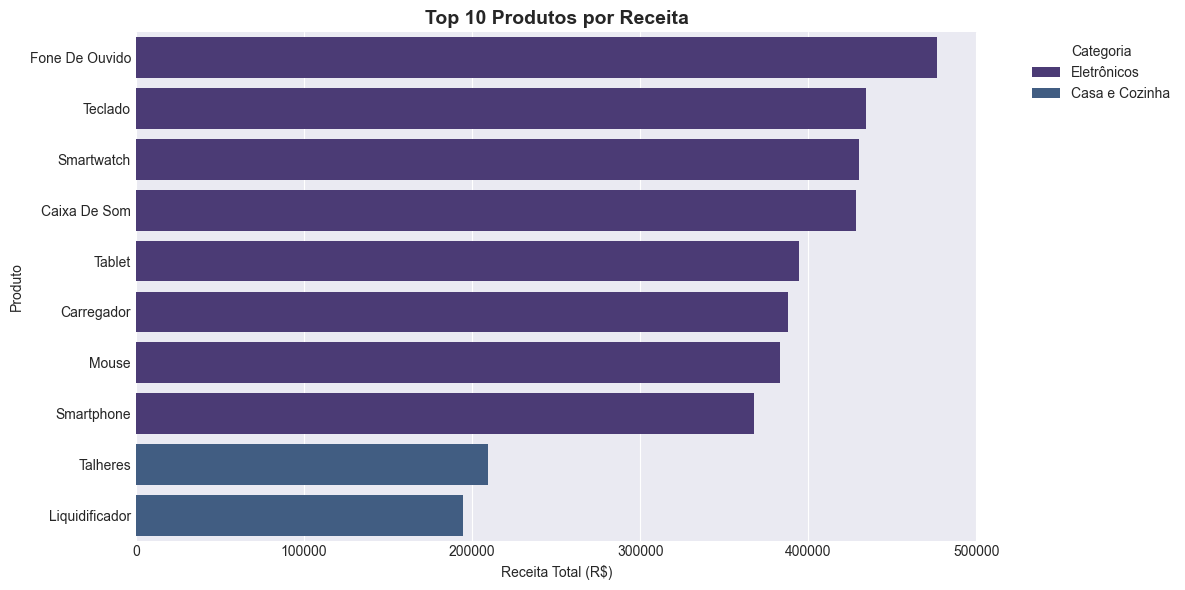

In [18]:
print("🏆 TOP 10 PRODUTOS")
print("=" * 60)

# Análise de produtos
top_produtos = df.groupby(['Nome_Produto', 'Categoria_Produto']).agg({
    'ID_Transacao': 'count',
    'Quantidade': 'sum',
    'Valor_Total': 'sum'
}).round(2)

top_produtos.columns = ['Qtd_Vendas', 'Unidades_Vendidas', 'Receita_Total']
top_produtos = top_produtos.reset_index()
top_produtos = top_produtos.sort_values('Receita_Total', ascending=False).head(10)

display(top_produtos)

# Visualização
plt.figure(figsize=(12, 6))
sns.barplot(data=top_produtos, y='Nome_Produto', x='Receita_Total', 
            hue='Categoria_Produto', dodge=False)
plt.title('Top 10 Produtos por Receita', fontsize=14, fontweight='bold')
plt.xlabel('Receita Total (R$)')
plt.ylabel('Produto')
plt.legend(title='Categoria', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

# 📊 PRINCIPAIS INSIGHTS DA SPRINT 2

## 1. Visão Geral
- **Total de vendas analisadas:** 5.390.
- **Período:** 01/01/23 - 31/12/24.
- **Receita total:** R$ 6.681.842,72
- **Ticket médio:** R$ 1.239,67

## 2. Desempenho por Categoria
- **Categoria com maior receita:** Eletrônicos.
- **Categoria com maior ticket médio:** {categoria_analise.loc[categoria_analise['Ticket_Medio'].idxmax(), 'Categoria_Produto']} (R$ {categoria_analise['Ticket_Medio'].max():.2f})

## 3. Sazonalidade
- **Melhor dia para vendas:** As sextas feiras foi registrado a maior Receita Total e Maior Ticket Médio comparado aos outros dias da semana
- **Mês com maior receita:** {vendas_mensais.loc[vendas_mensais['Receita_Total'].idxmax(), 'Ano_Mes']}
- **Mês com maior crescimento:** {vendas_mensais.loc[vendas_mensais['Crescimento_Receita'].idxmax(), 'Ano_Mes']} ({vendas_mensais['Crescimento_Receita'].max():.1f}%)

## 4. Outliers
- **Percentual de outliers:** {len(outliers_valor)/len(df)*100:.1f}%
- **Valor máximo (outlier):** R$ {outliers_valor['Valor_Total'].max():.2f}
- **Recomendação:** Investigar transações acima de R$ {lim_sup:.2f} para identificar possíveis erros ou clientes VIP

## 5. Segmentação de Clientes (RFM)

### Distribuição dos Segmentos:
"""
for _, row in segmentos.iterrows():
    print(f"- **{row['Segmento']}:** {row['Quantidade']} clientes ({row['Percentual']}%)")
"""

### Características por Segmento:
- **Campeões:** Clientes que compram frequentemente, gastam mais e compraram recentemente
- **Em Risco:** Clientes que não compram há muito tempo - necessário ação de reativação
- **Novatos:** Clientes recentes - oportunidade para fidelização

## 6. Correlações Importantes
- **Valor_Unitário x Valor_Total:** Correlação {correlacao.loc['Valor_Unitario', 'Valor_Total']:.2f} - [interpretação]
- **Quantidade x Valor_Total:** Correlação {correlacao.loc['Quantidade', 'Valor_Total']:.2f} - [interpretação]

## 7. Recomendações de Negócio

1. **Para clientes Campeões:** Criar programa de fidelidade com benefícios exclusivos
2. **Para clientes em Risco:** Campanha de reengajamento com cupons de desconto
3. **Para categoria top:** Aumentar estoque e criar combos com produtos relacionados
4. **Para sazonalidade:** Reforçar marketing nos dias/meses de maior venda
5. **Para outliers positivos:** Identificar clientes de alto valor para tratamento personalizado

In [19]:
# Salvar dados processados para uso no dashboard
print("💾 Salvando dados processados...")

# DataFrame principal com colunas derivadas
df.to_csv(os.path.join('..', 'data', 'dados_completos_processados.csv'), index=False)
print("✅ dados_completos_processados.csv salvo!")

# Top produtos
top_produtos.to_csv(os.path.join('..', 'data', 'top_produtos.csv'), index=False)
print("✅ top_produtos.csv salvo!")

# Análise de dias da semana
vendas_dia.to_csv(os.path.join('..', 'data', 'vendas_dia_semana.csv'), index=False)
print("✅ vendas_dia_semana.csv salvo!")

# Fechar conexão com banco
conn.close()
print("\n🔌 Conexão com banco de dados fechada!")

print("\n🎉 SPRINT 2 CONCLUÍDA COM SUCESSO!")
print("Os dados estão prontos para o dashboard na Sprint 3!")

💾 Salvando dados processados...
✅ dados_completos_processados.csv salvo!
✅ top_produtos.csv salvo!
✅ vendas_dia_semana.csv salvo!

🔌 Conexão com banco de dados fechada!

🎉 SPRINT 2 CONCLUÍDA COM SUCESSO!
Os dados estão prontos para o dashboard na Sprint 3!
